에이전트 설계

1. 에이전트 이름
Jeju-Travel-Planner

2. 목적
사용자의 취향을 대화를 통해 구조화하고,
이를 바탕으로 제주 여행 일정 초안을 만들어서
여행의 기초 뼈대를 생성할 수 있게 도와준다.

3. 핵심 기능
a. 여행 취향 추출
    - 사용자 자연어에서 여행 기간, 교통수단, 선호 테마 등을 추출한다.

b. 여행 경로 생성
    - 추출한 취향을 여행 조건 데이터 만든다.
    - 이후 장소 검색과 일정 생성의 입력값으로 사용한다.

c. 여행 경로 수정
    - 생성된 경로를 대화를 통해 수정할 수 있다.

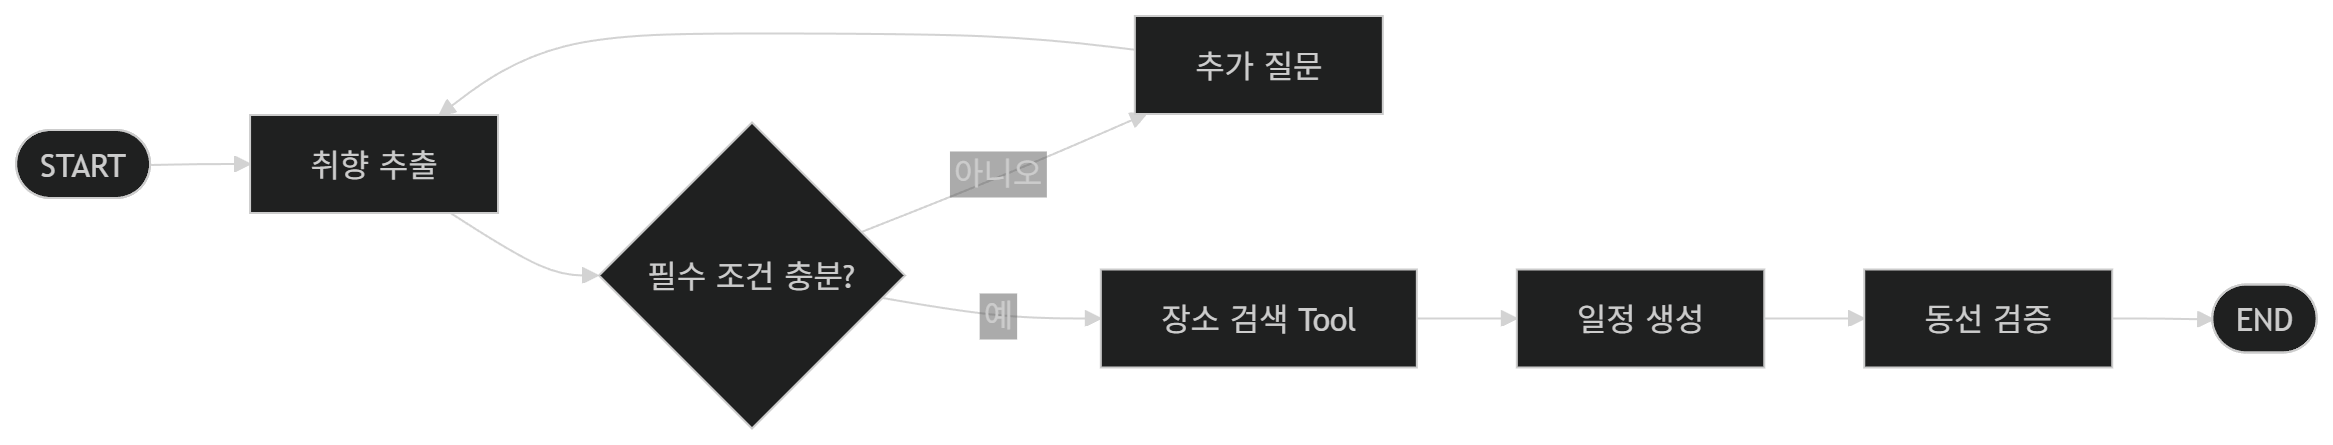

In [7]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

In [8]:
class TravelPreferences(TypedDict, total=False):
    travel_days: int | None
    party_type: str
    transportation_type: str
    preferred_themes: list[str]
    preferred_area: str
    missing_fields: list[str]


class State(TypedDict):
    user_request: str
    travel_info: dict
    travel_brief: str

In [9]:
def collect_preferences(state: State):
    user_request = state["user_request"]
    # 추후 자연어를 travel_info로 변환하는 로직 추가.
    travel_info = {
        "request": user_request,
        "party_type": "가족" if "가족" in user_request else "미정",
        "transportation_type": (
            "렌터카" if "렌터카" in user_request else "미정"
        ),
    }

    return {
        "travel_info": travel_info,
    }


def create_travel_brief(state: State):
    preferences = state["travel_info"]

    travel_brief = (
        "여행 조건 요약\n"
        f"- 동행: {preferences['party_type']}\n"
        f"- 이동수단: {preferences['transportation_type']}"
    )

    return {
        "travel_brief": travel_brief,
    }

In [10]:
graph_builder = StateGraph(State)

graph_builder.add_node("collect_preferences", collect_preferences)
graph_builder.add_node("create_travel_brief", create_travel_brief)

graph_builder.add_edge(START, "collect_preferences")
graph_builder.add_edge("collect_preferences", "create_travel_brief")
graph_builder.add_edge("create_travel_brief", END)

In [11]:
graph = graph_builder.compile()
graph.invoke({"user_request": (
                "제주 2박 3일로 가족과 갈 거예요. "
                "렌터카를 빌리고 애월에 숙소를 잡고 싶어요."
                "바다 보면서 카페와 맛집을 많이 가고 싶습니다."
            )})

{'user_request': '제주 2박 3일로 가족과 갈 거예요. 렌터카를 빌리고 애월에 숙소를 잡고 싶어요.바다 보면서 카페와 맛집을 많이 가고 싶습니다.',
 'travel_info': {'request': '제주 2박 3일로 가족과 갈 거예요. 렌터카를 빌리고 애월에 숙소를 잡고 싶어요.바다 보면서 카페와 맛집을 많이 가고 싶습니다.',
  'party_type': '가족',
  'transportation_type': '렌터카'},
 'travel_brief': '여행 조건 요약\n- 동행: 가족\n- 이동수단: 렌터카'}